In [ ]:
# Import library analitik dan visualisasi standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Konfigurasi parameter visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Inisialisasi dataset
df = pd.read_csv('/content/marketing_campaign_for_vinix.csv')

display(df.head())
display(df.info())

,Tanggal,Region_Code,Promo_Active,Daily_Ad_Spend,Website_Traffic,Daily_Revenue
0,2023-09-20,JABODETABEK,CASHBACK 50K,2162246.0,7600,Rp 49.362.908
1,2023-12-16,SULAWESI,cashback 50k,2724843.0,2970,Rp 19.980.313
2,2023-08-26,JABODETABEK,DISKON 20%,1186002.0,5667,Rp 75.667.735
3,2023-12-16,JAWA TIMUR,DISKON 20%,2079296.0,6108,Rp 74.303.388
4,2023-11-08,JABODETABEK,cashback 50k,2418979.0,8052,Rp 62.127.957


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tanggal          1104 non-null   object 
 1   Region_Code      1104 non-null   object 
 2   Promo_Active     1104 non-null   object 
 3   Daily_Ad_Spend   1060 non-null   float64
 4   Website_Traffic  1104 non-null   int64  
 5   Daily_Revenue    1104 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 51.9+ KB


None

In [ ]:
# cek nilai null dan duplikasi data
display(df.isnull().sum())
display(df.duplicated().sum())

,0
Tanggal,0
Region_Code,0
Promo_Active,0
Daily_Ad_Spend,44
Website_Traffic,0
Daily_Revenue,0


np.int64(0)

In [ ]:
# hapus nilai null dan data duplikat
df = df.dropna()
df = df.drop_duplicates()

# cek nilai null dan duplikasi data
display(df.isnull().sum())
display(df.duplicated().sum())

,0
Tanggal,0
Region_Code,0
Promo_Active,0
Daily_Ad_Spend,0
Website_Traffic,0
Daily_Revenue,0


np.int64(0)

# 1. Data Inspection & Profiling

In [ ]:
# Inspeksi nilai unik pada kolom kategorikal
print("Nilai unik pada kolom Promo_Active (Sebelum Cleaning):")
print(df['Promo_Active'].unique())

# Inspeksi sampel data pada kolom numerik yang kotor
print("\nSampel 5 data teratas pada kolom Daily_Revenue:")
print(df['Daily_Revenue'].head())

Nilai unik pada kolom Promo_Active (Sebelum Cleaning):
[' CASHBACK 50K ' 'cashback 50k' ' DISKON 20% ' 'Diskon 20%' 'Diskon 20 %'
 'diskon 20%' 'Diskon-20%' 'CB 50K' 'Cashback 50K' 'Cashback 50k']

Sampel 5 data teratas pada kolom Daily_Revenue:
0    Rp 49.362.908
1    Rp 19.980.313
2    Rp 75.667.735
3    Rp 74.303.388
4    Rp 62.127.957
Name: Daily_Revenue, dtype: object


# 2. Data Standarization

In [ ]:
# 2A. Standarisasi Kolom Kategorikal (Training_Type)
df['Promo_Active'] = df['Promo_Active'].str.upper().str.strip() # Menjadikan ke lowercase (huruf kecil semua)
df['Promo_Active'] = df['Promo_Active'].replace('CB 50K', 'CASHBACK 50K') # Menangani typo spesifik
df['Promo_Active'] = df['Promo_Active'].replace('DISKON-20%', 'DISKON 20%') # Menangani typo spesifik
df['Promo_Active'] = df['Promo_Active'].replace('DISKON 20 %', 'DISKON 20%') # Menangani typo spesifik

# Verifikasi distribusi kategori paska-standarisasi
print("Distribusi Kategori Training (Setelah Cleaning):")
print(df['Promo_Active'].value_counts())

Distribusi Kategori Training (Setelah Cleaning):
Promo_Active
DISKON 20%      569
CASHBACK 50K    491
Name: count, dtype: int64


In [ ]:
# 2B. Standarisasi Kolom Numerik (Daily_Revenue)
# Ekstraksi karakter non-numerik (Rp, IDR, titik pemisah ribuan)
df['Daily_Revenue'] = df['Daily_Revenue'].str.replace('Rp', '', regex=False)
df['Daily_Revenue'] = df['Daily_Revenue'].str.replace('.', '', regex=False)

# Konversi vektor tipe data ke numerik
df['Daily_Revenue'] = df['Daily_Revenue'].astype(float)

display(df[['Daily_Revenue']].describe().T)

,count,mean,std,min,25%,50%,75%,max
Daily_Revenue,1060.0,5.595307e+07,3.451105e+07,170862.0,30790191.5,47536202.5,74790009.0,227393918.0


2. Outlier Detection & Mitigation
Analisis regresi sangat sensitif terhadap nilai ekstrem (*leverage points*).
Verifikasi visual menggunakan *Scatter Plot* dilakukan untuk mengidentifikasi anomali pada variabel independen (`Daily_Ad_Spend`).

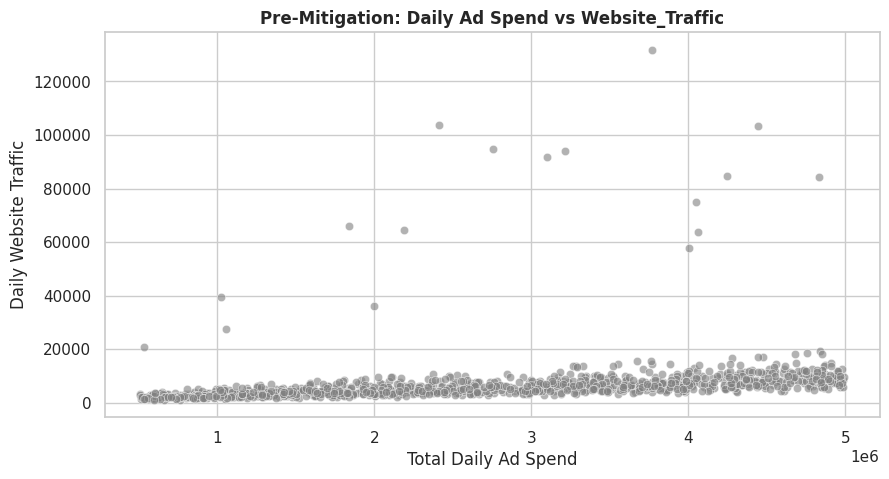

In [ ]:
# Diagnostik visual: Identifikasi anomali sebaran data
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Daily_Ad_Spend', y='Website_Traffic', alpha=0.6, color='gray')
plt.title("Pre-Mitigation: Daily Ad Spend vs Website_Traffic", fontweight='bold')
plt.xlabel("Total Daily Ad Spend")
plt.ylabel("Daily Website Traffic")
plt.show()

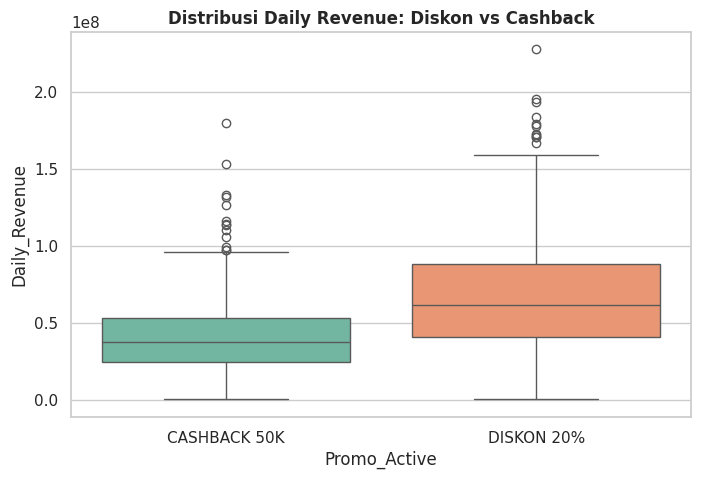

In [ ]:
# Visualisasi Distribusi (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Promo_Active', y='Daily_Revenue', palette='Set2')
plt.title("Distribusi Daily Revenue: Diskon vs Cashback", fontweight='bold')
plt.show()

In [ ]:
df

,Tanggal,Region_Code,Promo_Active,Daily_Ad_Spend,Website_Traffic,Daily_Revenue
0,2023-09-20,JABODETABEK,CASHBACK 50K,2162246.0,7600,49362908.0
1,2023-12-16,SULAWESI,CASHBACK 50K,2724843.0,2970,19980313.0
2,2023-08-26,JABODETABEK,DISKON 20%,1186002.0,5667,75667735.0
3,2023-12-16,JAWA TIMUR,DISKON 20%,2079296.0,6108,74303388.0
4,2023-11-08,JABODETABEK,CASHBACK 50K,2418979.0,8052,62127957.0
...,...,...,...,...,...,...
1097,2023-07-13,JAWA BARAT,DISKON 20%,1224338.0,4082,56604473.0
1098,2023-07-08,BALI,CASHBACK 50K,3025529.0,4580,39128144.0
1099,2023-10-15,JAWA TIMUR,DISKON 20%,3984549.0,8240,88938427.0
1100,2023-07-19,BALI,DISKON 20%,2444177.0,3917,56866954.0


In [ ]:
df.describe()

,Daily_Ad_Spend,Website_Traffic,Daily_Revenue
count,1.060000e+03,1060.000000,1.060000e+03
mean,2.713631e+06,6920.311321,5.595307e+07
std,1.328340e+06,9686.334654,3.451105e+07
min,5.052030e+05,1143.000000,1.708620e+05
25%,1.540663e+06,3573.750000,3.079019e+07
50%,2.648995e+06,5376.500000,4.753620e+07
75%,3.868024e+06,7679.750000,7.479001e+07
max,4.992336e+06,131833.000000,2.273939e+08


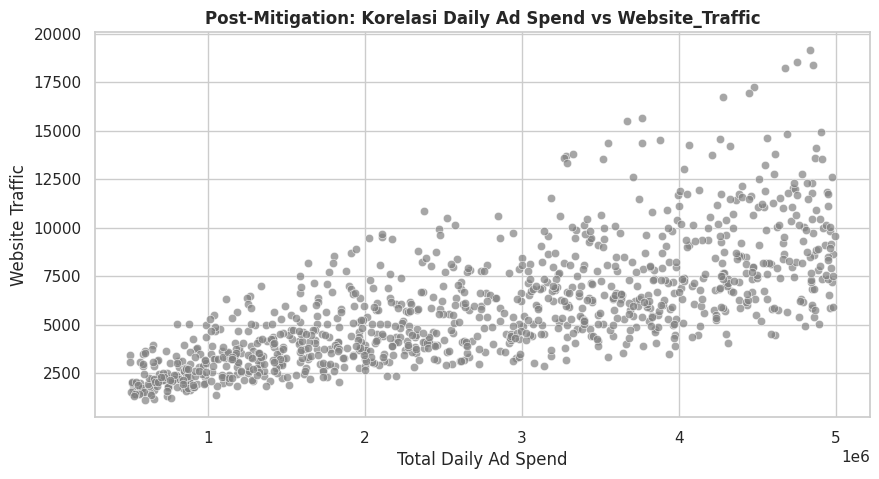

In [ ]:
# Eksekusi pembersihan nilai ekstrem (Treshold: Kunjungan < 10000)
df_clean = df[(df['Website_Traffic'] < 20000)].copy()

# Validasi visual paska-mitigasi
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='Daily_Ad_Spend', y='Website_Traffic', alpha=0.7, color='gray')
plt.title("Post-Mitigation: Korelasi Daily Ad Spend vs Website_Traffic", fontweight='bold')
plt.xlabel("Total Daily Ad Spend")
plt.ylabel("Website Traffic")
plt.show()

## 3. Hypothesis Testing: Efektivitas Program Pelatihan
**Objective:** Menguji probabilitas signifikansi perbedaan rata-rata pendapatan antara promosi *Diskon 20%* dan *Cashback 50k*.
* $H_0$: $\mu_{Diskon} = \mu_{Cashback}$ (Tidak ada perbedaan signifikan).
* $H_1$: $\mu_{Diskon} \neq \mu_{Cashback}$ (Terdapat perbedaan signifikan).
* Level Signifikansi ($\alpha$): 0.05

--- Hasil Audit Statistik (Independent T-Test) ---
T-Statistic : 12.9415
P-Value     : 0.00000000000000000000000000000000001

Kesimpulan: H0 ditolak. Terdapat perbedaan signifikan secara statistik pada Daily Revenue berdasarkan jenis promo.


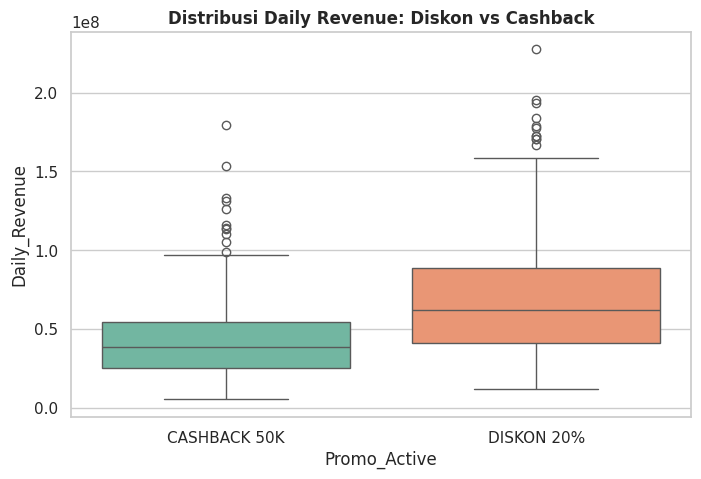

In [ ]:
# Pemisahan array populasi
rev_DISKON = df_clean[df_clean['Promo_Active'] == 'DISKON 20%']['Daily_Revenue']
rev_CASHBACK  = df_clean[df_clean['Promo_Active'] == 'CASHBACK 50K']['Daily_Revenue']

# Eksekusi Independent T-Test (Asumsi variansi ekuivalen)
t_stat, p_value = stats.ttest_ind(rev_DISKON, rev_CASHBACK, equal_var=True)

print("--- Hasil Audit Statistik (Independent T-Test) ---")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.35f}")

if p_value < 0.05:
    print("\nKesimpulan: H0 ditolak. Terdapat perbedaan signifikan secara statistik pada Daily Revenue berdasarkan jenis promo.")
else:
    print("\nKesimpulan: H0 gagal ditolak. Tidak ada bukti statistik yang cukup atas perbedaan revenue.")

# Visualisasi Distribusi (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Promo_Active', y='Daily_Revenue', palette='Set2')
plt.title("Distribusi Daily Revenue: Diskon vs Cashback", fontweight='bold')
plt.show()

## 4. Analisis Regresi

Untuk melihat seberapa besar pengaruh *Ad Spend* terhadap *Traffic*

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1369.4392    147.409      9.290      0.000    1080.187    1658.691
Daily_Ad_Spend     0.0017   4.88e-05     33.809      0.000       0.002       0.002

R-Squared Value: 0.5234


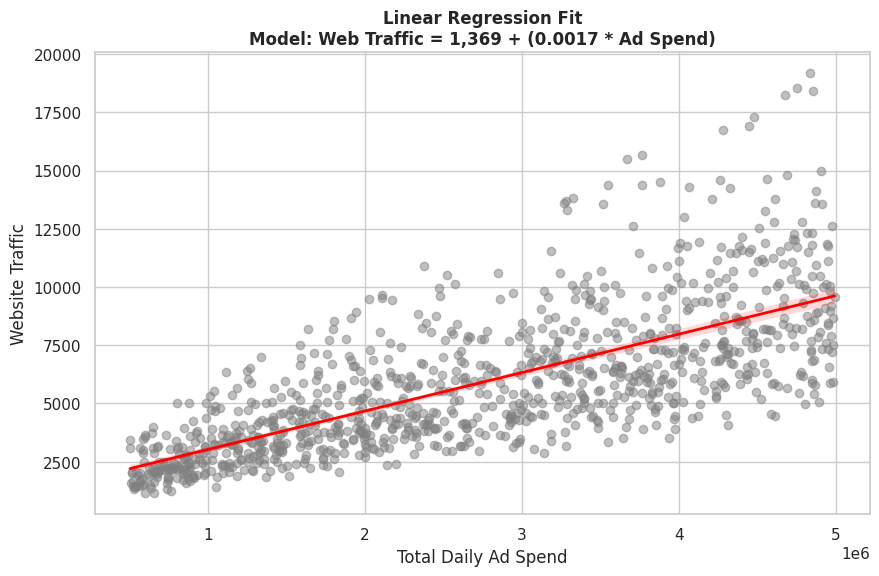

In [ ]:
# Konstruksi variabel independen (X) dan dependen (Y)
X = df_clean['Daily_Ad_Spend']
Y = df_clean['Website_Traffic']

# Menambahkan konstanta (Intercept) untuk model statsmodels
X_const = sm.add_constant(X)

# Fitting Model OLS
ols_model = sm.OLS(Y, X_const).fit()

# Menampilkan ringkasan metrik statistik
print(ols_model.summary().tables[1])
print(f"\nR-Squared Value: {ols_model.rsquared:.4f}")

# Ekstraksi parameter garis lurus (y = mx + c)
intercept = ols_model.params['const']
slope = ols_model.params['Daily_Ad_Spend']

# Visualisasi Garis Regresi Terbaik (Line of Best Fit)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Daily_Ad_Spend', y='Website_Traffic',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'linewidth':2}, color='gray')
plt.title(f"Linear Regression Fit\nModel: Web Traffic = {intercept:,.0f} + ({slope:,.4f} * Ad Spend)", fontweight='bold')
plt.xlabel("Total Daily Ad Spend")
plt.ylabel("Website Traffic")
plt.show()